# AntMaze-Medium: Algorithm Comparison Plots

Comparison of 9 imitation learning algorithms (1 expert + 4 causal + 4 naive) evaluated on 1000 episodes each.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({'font.size': 12})

In [2]:
# --- Data extracted from out_test_*.ipynb notebooks (1000 eval episodes each) ---

algorithms = [
    'Expert',
    'Causal BC', 'Causal GAIL', 'Causal SQIL', 'Causal IQLearn',
    'Naive BC',  'Naive GAIL',  'Naive SQIL',  'Naive IQLearn',
]

# E[Y] and Std[Y]
mean_rewards = np.array([
    -103.9545,   # Expert
    -154.0120,   # Causal BC
    -186.0156,   # Causal GAIL
    -135.9300,   # Causal SQIL
    -142.4897,   # Causal IQLearn
    -375.3281,   # Naive BC
    -364.8926,   # Naive GAIL
    -370.6745,   # Naive SQIL
    -372.5462,   # Naive IQLearn
])

std_rewards = np.array([
    87.5173,     # Expert
    113.8964,    # Causal BC
    122.9877,    # Causal GAIL
    110.0002,    # Causal SQIL
    111.5273,    # Causal IQLearn
    119.1750,    # Naive BC
    112.2076,    # Naive GAIL
    119.0691,    # Naive SQIL
    120.8261,    # Naive IQLearn
])

# Success rates and standard errors
success_rates = np.array([
    87.60,  # Expert
    66.00,  # Causal BC
    57.20,  # Causal GAIL
    76.70,  # Causal SQIL
    74.00,  # Causal IQLearn
    0.00,   # Naive BC
    0.00,   # Naive GAIL
    0.00,   # Naive SQIL
    0.00,   # Naive IQLearn
])

success_se = np.array([
    1.04,  # Expert
    1.50,  # Causal BC
    1.56,  # Causal GAIL
    1.34,  # Causal SQIL
    1.39,  # Causal IQLearn
    0.00,  # Naive BC
    0.00,  # Naive GAIL
    0.00,  # Naive SQIL
    0.00,  # Naive IQLearn
])

# Successful episode lengths (mean, std) — only for algorithms with successes
# Naive algorithms have 0% success, so no episode length data
succ_len_mean = np.array([
    301.34,  # Expert
    357.84,  # Causal BC
    390.39,  # Causal GAIL
    330.74,  # Causal SQIL
    351.47,  # Causal IQLearn
    np.nan,  # Naive BC
    np.nan,  # Naive GAIL
    np.nan,  # Naive SQIL
    np.nan,  # Naive IQLearn
])

succ_len_std = np.array([
    57.08,   # Expert
    112.12,  # Causal BC
    119.09,  # Causal GAIL
    91.18,   # Causal SQIL
    86.38,   # Causal IQLearn
    np.nan,  # Naive BC
    np.nan,  # Naive GAIL
    np.nan,  # Naive SQIL
    np.nan,  # Naive IQLearn
])

# Colors: gold for expert, blues for causal, reds for naive
colors = [
    '#FFD700',  # Expert — gold
    '#1f77b4',  # Causal BC
    '#2ca02c',  # Causal GAIL
    '#17becf',  # Causal SQIL
    '#9467bd',  # Causal IQLearn
    '#d62728',  # Naive BC
    '#ff7f0e',  # Naive GAIL
    '#e377c2',  # Naive SQIL
    '#8c564b',  # Naive IQLearn
]

x = np.arange(len(algorithms))

## 1. E[Y] — Mean Episode Return

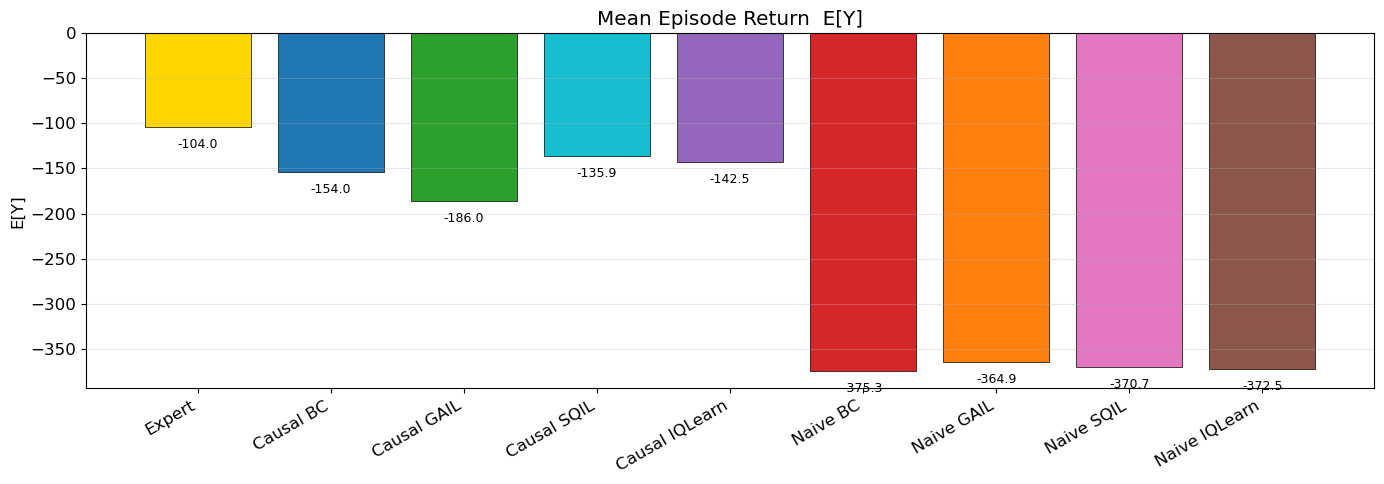

In [3]:
# E[Y] without std
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(x, mean_rewards, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(algorithms, rotation=30, ha='right')
ax.set_ylabel('E[Y]')
ax.set_title('Mean Episode Return  E[Y]')
ax.axhline(y=0, color='grey', linewidth=0.5)
for i, v in enumerate(mean_rewards):
    ax.text(i, v - 12, f'{v:.1f}', ha='center', va='top', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

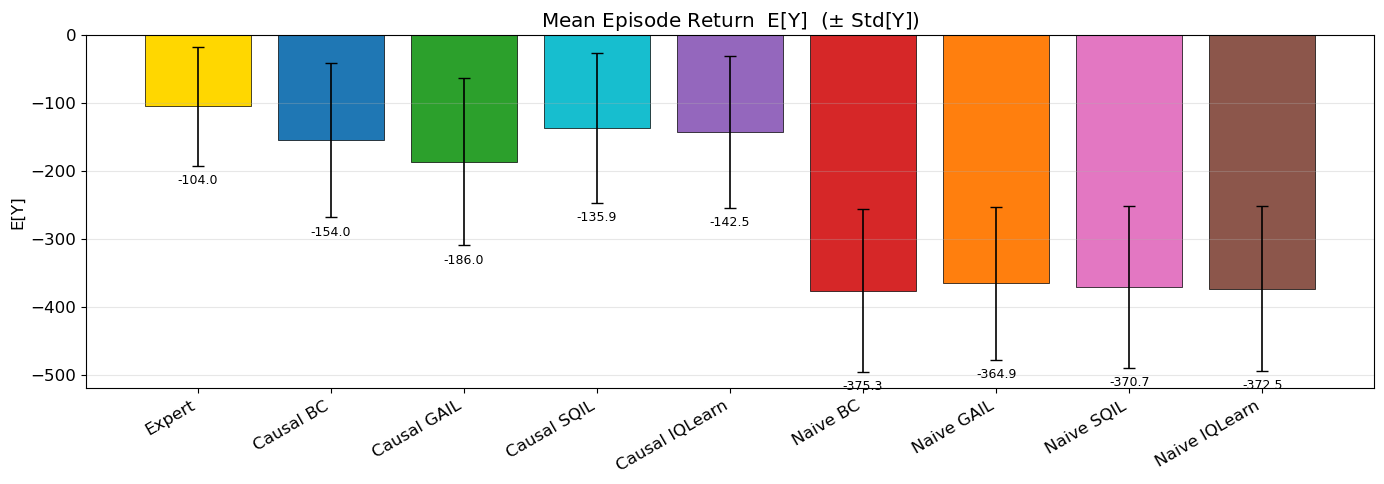

In [4]:
# E[Y] with std
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(x, mean_rewards, yerr=std_rewards, capsize=4,
              color=colors, edgecolor='black', linewidth=0.5,
              error_kw={'linewidth': 1.2})
ax.set_xticks(x)
ax.set_xticklabels(algorithms, rotation=30, ha='right')
ax.set_ylabel('E[Y]')
ax.set_title('Mean Episode Return  E[Y]  ($\\pm$ Std[Y])')
ax.axhline(y=0, color='grey', linewidth=0.5)
for i, (m, s) in enumerate(zip(mean_rewards, std_rewards)):
    ax.text(i, m - s - 12, f'{m:.1f}', ha='center', va='top', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Normalized E[Y]  (relative to Expert)

In [5]:
# Normalize: expert = 1.0, worst possible (all -1 * num_steps) = 0
# The worst raw return observed across naive methods is ~-375;
# a random/stuck agent gets -1 per step for 1000 steps => -1000.
# We normalize as:  norm = (reward - worst) / (expert - worst)
# where worst = -1000  (maximum penalty for a full episode)

worst_return = -1000.0
expert_return = mean_rewards[0]

norm_mean = (mean_rewards - worst_return) / (expert_return - worst_return)
norm_std  = std_rewards / abs(expert_return - worst_return)

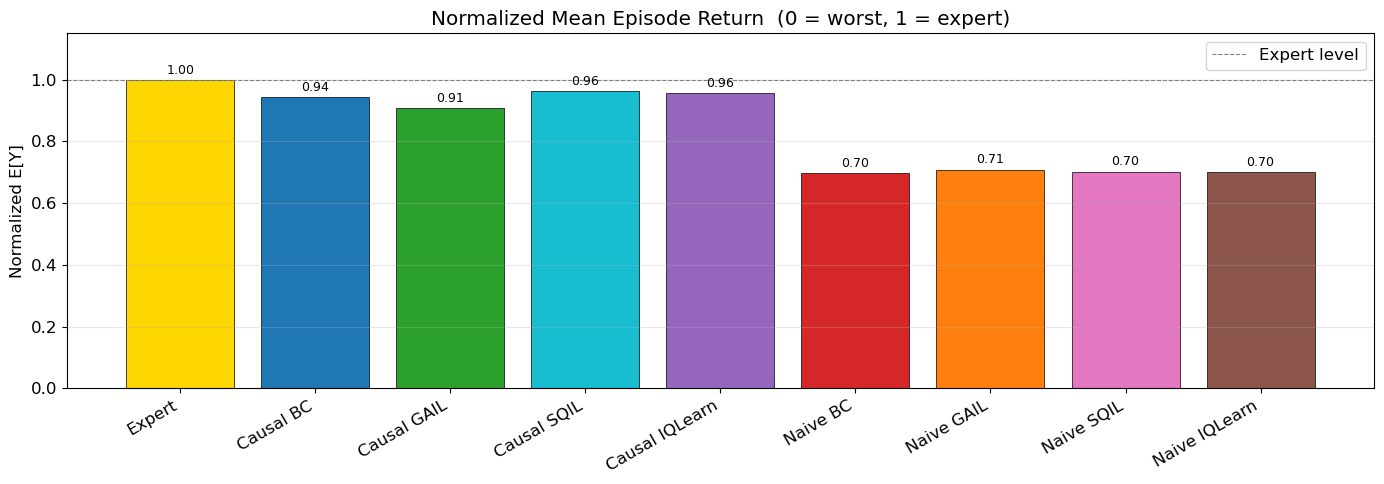

In [6]:
# Normalized E[Y] without std
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(x, norm_mean, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(algorithms, rotation=30, ha='right')
ax.set_ylabel('Normalized E[Y]')
ax.set_title('Normalized Mean Episode Return  (0 = worst, 1 = expert)')
ax.axhline(y=1.0, color='grey', linewidth=0.8, linestyle='--', label='Expert level')
for i, v in enumerate(norm_mean):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

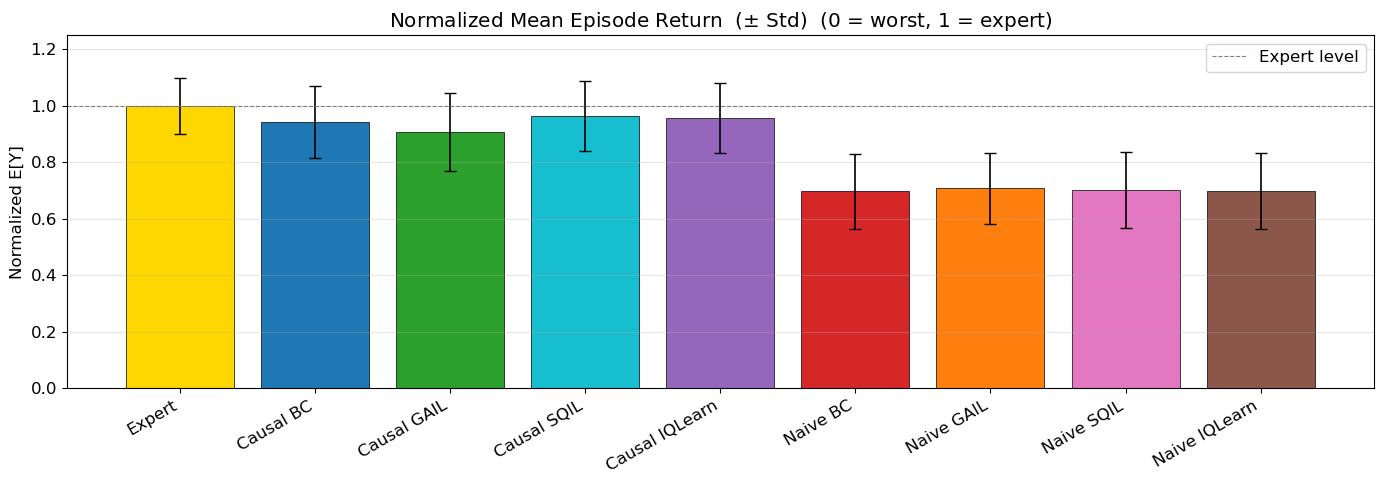

In [7]:
# Normalized E[Y] with std
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(x, norm_mean, yerr=norm_std, capsize=4,
              color=colors, edgecolor='black', linewidth=0.5,
              error_kw={'linewidth': 1.2})
ax.set_xticks(x)
ax.set_xticklabels(algorithms, rotation=30, ha='right')
ax.set_ylabel('Normalized E[Y]')
ax.set_title('Normalized Mean Episode Return  ($\\pm$ Std)  (0 = worst, 1 = expert)')
ax.axhline(y=1.0, color='grey', linewidth=0.8, linestyle='--', label='Expert level')
ax.set_ylim(0, 1.25)
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Success Rate (% of Solved Mazes)

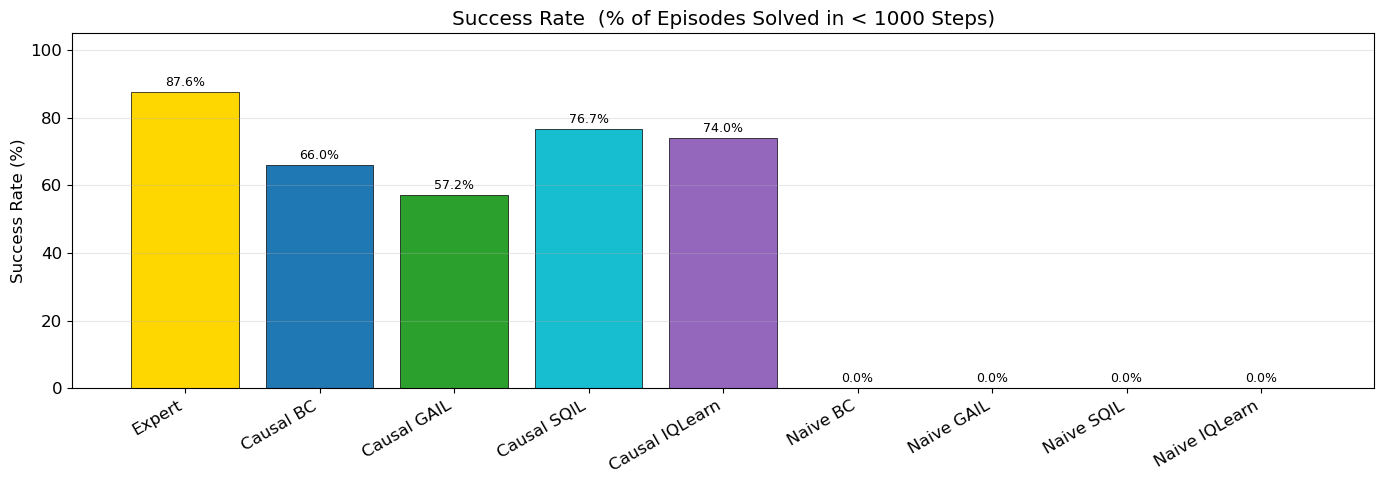

In [8]:
# Success rate without std error
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(x, success_rates, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(algorithms, rotation=30, ha='right')
ax.set_ylabel('Success Rate (%)')
ax.set_title('Success Rate  (% of Episodes Solved in < 1000 Steps)')
for i, v in enumerate(success_rates):
    ax.text(i, v + 1.0, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

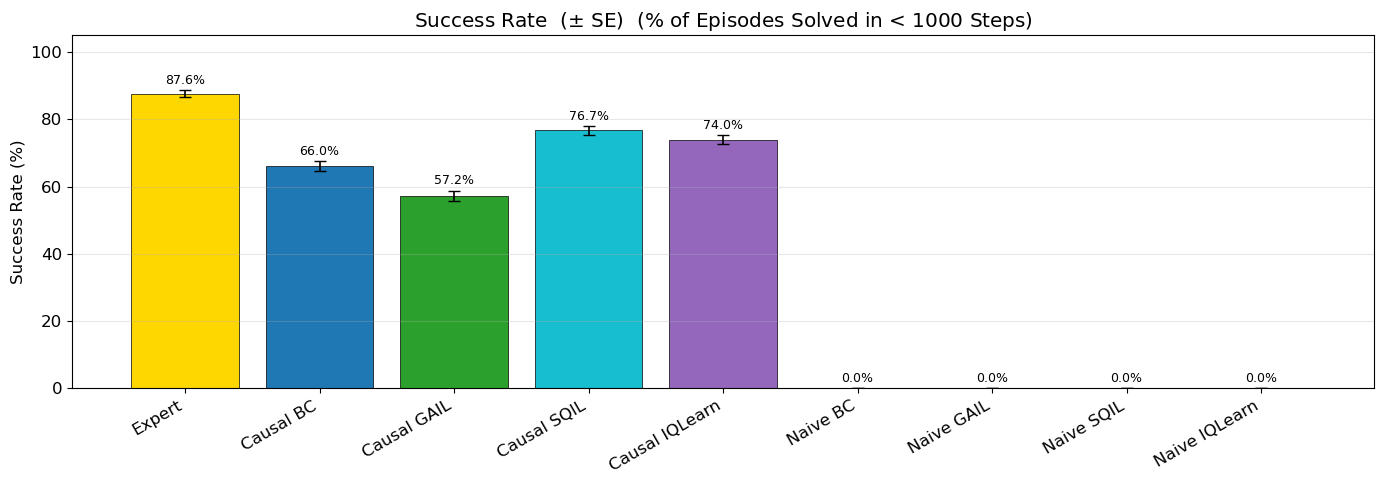

In [9]:
# Success rate with std error
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(x, success_rates, yerr=success_se, capsize=4,
              color=colors, edgecolor='black', linewidth=0.5,
              error_kw={'linewidth': 1.2})
ax.set_xticks(x)
ax.set_xticklabels(algorithms, rotation=30, ha='right')
ax.set_ylabel('Success Rate (%)')
ax.set_title('Success Rate  ($\\pm$ SE)  (% of Episodes Solved in < 1000 Steps)')
for i, (v, se) in enumerate(zip(success_rates, success_se)):
    ax.text(i, v + se + 1.0, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Successful Episode Lengths

Only algorithms with at least one successful episode are shown. Naive BC, Naive GAIL, Naive SQIL, and Naive IQLearn all have 0% success rate.

In [10]:
# Filter to algorithms with successful episodes
mask = ~np.isnan(succ_len_mean)
succ_algos   = [a for a, m in zip(algorithms, mask) if m]
succ_means   = succ_len_mean[mask]
succ_stds    = succ_len_std[mask]
succ_colors  = [c for c, m in zip(colors, mask) if m]
x_succ = np.arange(len(succ_algos))

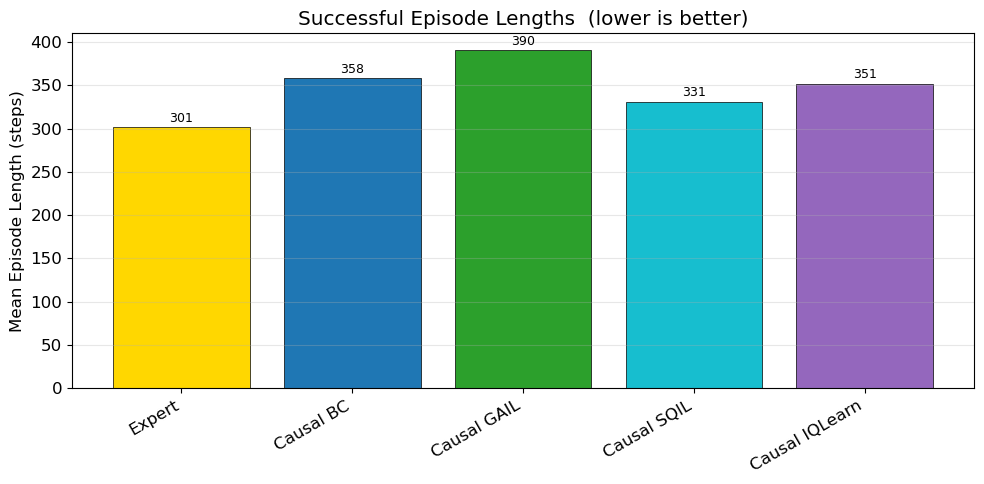

In [11]:
# Successful episode lengths without std
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x_succ, succ_means, color=succ_colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(x_succ)
ax.set_xticklabels(succ_algos, rotation=30, ha='right')
ax.set_ylabel('Mean Episode Length (steps)')
ax.set_title('Successful Episode Lengths  (lower is better)')
for i, v in enumerate(succ_means):
    ax.text(i, v + 3, f'{v:.0f}', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

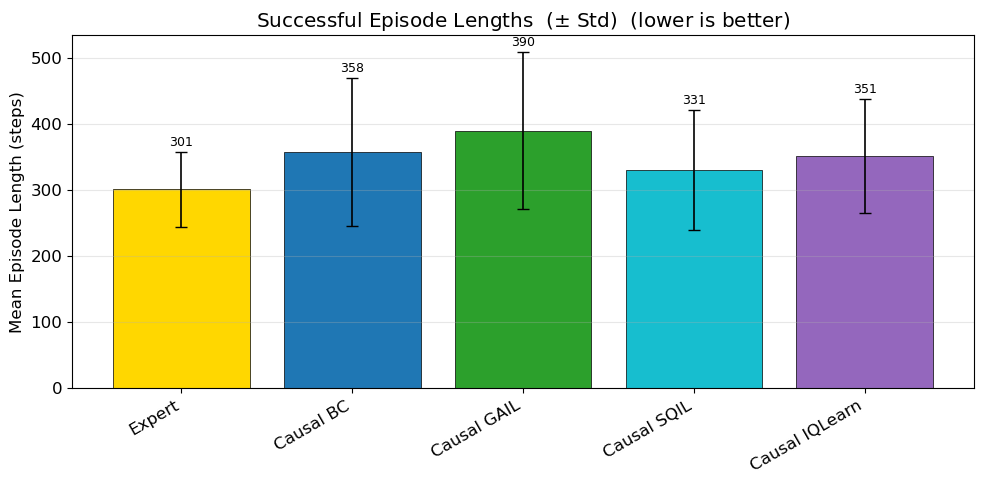

In [12]:
# Successful episode lengths with std
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x_succ, succ_means, yerr=succ_stds, capsize=4,
              color=succ_colors, edgecolor='black', linewidth=0.5,
              error_kw={'linewidth': 1.2})
ax.set_xticks(x_succ)
ax.set_xticklabels(succ_algos, rotation=30, ha='right')
ax.set_ylabel('Mean Episode Length (steps)')
ax.set_title('Successful Episode Lengths  ($\\pm$ Std)  (lower is better)')
for i, (m, s) in enumerate(zip(succ_means, succ_stds)):
    ax.text(i, m + s + 5, f'{m:.0f}', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()